In [1]:
# 1. Import Dependencies
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

In [2]:
# 2. Data Loading and Preprocessing
df = pd.read_csv("extracted_columns.csv")
X = df[['PSS-1', 'PSS-2', 'PSS-3', 'PSS-4', 'PSS-5', 'PSS-6', 'PSS-7', 
        'PSS-8', 'PSS-9', 'PSS-10', 'PSS-11', 'PSS-12', 'PSS-13', 'PSS-14']]
df['PSS_total'] = X.sum(axis=1)
y = df['PSS_total']

In [3]:
# 3. Random Forest Hyperparameter Bounds
rfr_param_bounds = {
    'n_estimators': [50, 200],
    'max_depth': [None, 5, 10, 20, 50],
    'min_samples_split': [2, 10],
    'min_samples_leaf': [1, 5]
}


In [5]:
# 4. PSO Implementation
def create_particle():
    # Position: [n_estimators, max_depth_idx, min_samples_split, min_samples_leaf]
    return {
        'position': [
            np.random.uniform(rfr_param_bounds['n_estimators'][0], rfr_param_bounds['n_estimators'][1]),
            np.random.randint(0, len(rfr_param_bounds['max_depth'])),
            np.random.uniform(rfr_param_bounds['min_samples_split'][0], rfr_param_bounds['min_samples_split'][1]),
            np.random.uniform(rfr_param_bounds['min_samples_leaf'][0], rfr_param_bounds['min_samples_leaf'][1])
        ],
        'velocity': [0, 0, 0, 0],
        'best_position': None,
        'best_fitness': -np.inf
    }
def decode_particle_position(position):
    return {
        'n_estimators': int(np.clip(position[0], rfr_param_bounds['n_estimators'][0], rfr_param_bounds['n_estimators'][1])),
        'max_depth': rfr_param_bounds['max_depth'][int(np.clip(position[1], 0, len(rfr_param_bounds['max_depth'])-1))],
        'min_samples_split': int(np.clip(position[2], rfr_param_bounds['min_samples_split'][0], rfr_param_bounds['min_samples_split'][1])),
        'min_samples_leaf': int(np.clip(position[3], rfr_param_bounds['min_samples_leaf'][0], rfr_param_bounds['min_samples_leaf'][1]))
    }

def fitness_rfr(params, X_train, y_train, X_val, y_val):
    model = RandomForestRegressor(
        n_estimators=params['n_estimators'],
        max_depth=params['max_depth'],
        min_samples_split=params['min_samples_split'],
        min_samples_leaf=params['min_samples_leaf'],
        random_state=42
    )
    model.fit(X_train, y_train)
    preds = model.predict(X_val)
    return -np.sqrt(mean_squared_error(y_val, preds))

def pso_rfr(X, y, generations=10, swarm_size=20, w=0.7, c1=1.5, c2=1.5):
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
    swarm = [create_particle() for _ in range(swarm_size)]
    global_best_position = None
    global_best_fitness = -np.inf

    for particle in swarm:
        params = decode_particle_position(particle['position'])
        fitness = fitness_rfr(params, X_train, y_train, X_val, y_val)
        particle['best_position'] = particle['position'][:]
        particle['best_fitness'] = fitness
        if fitness > global_best_fitness:
            global_best_fitness = fitness
            global_best_position = particle['position'][:]

    for gen in range(generations):
        for particle in swarm:
            for i in range(4):
                r1, r2 = np.random.rand(), np.random.rand()
                cognitive = c1 * r1 * (particle['best_position'][i] - particle['position'][i])
                social = c2 * r2 * (global_best_position[i] - particle['position'][i])
                particle['velocity'][i] = w * particle['velocity'][i] + cognitive + social
                particle['position'][i] += particle['velocity'][i]
            params = decode_particle_position(particle['position'])
            fitness = fitness_rfr(params, X_train, y_train, X_val, y_val)
            if fitness > particle['best_fitness']:
                particle['best_fitness'] = fitness
                particle['best_position'] = particle['position'][:]
            if fitness > global_best_fitness:
                global_best_fitness = fitness
                global_best_position = particle['position'][:]
        best_params = decode_particle_position(global_best_position)
        print(f"Generation {gen+1}, Best RMSE: {-global_best_fitness:.4f}, Params: {best_params}")

    best_params = decode_particle_position(global_best_position)
    return best_params, X_train, X_val, y_train, y_val


In [7]:
# 5. Model Evaluation
def evaluate_and_plot(model_name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"{model_name} RMSE:", rmse)
    print(f"{model_name} MAE:", mae)
    print(f"{model_name} R^2:", r2)
    plt.figure(figsize=(8,6))
    plt.scatter(y_true, y_pred, alpha=0.6)
    plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--')
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title(f'{model_name}: Actual vs Predicted')
    plt.show()

Generation 1, Best RMSE: 1.8624, Params: {'n_estimators': 121, 'max_depth': 50, 'min_samples_split': 3, 'min_samples_leaf': 1}
Generation 2, Best RMSE: 1.8472, Params: {'n_estimators': 200, 'max_depth': 50, 'min_samples_split': 2, 'min_samples_leaf': 1}
Generation 3, Best RMSE: 1.8472, Params: {'n_estimators': 200, 'max_depth': 50, 'min_samples_split': 2, 'min_samples_leaf': 1}
Generation 4, Best RMSE: 1.8472, Params: {'n_estimators': 200, 'max_depth': 50, 'min_samples_split': 2, 'min_samples_leaf': 1}
Generation 5, Best RMSE: 1.8472, Params: {'n_estimators': 200, 'max_depth': 50, 'min_samples_split': 2, 'min_samples_leaf': 1}
Generation 6, Best RMSE: 1.8472, Params: {'n_estimators': 200, 'max_depth': 50, 'min_samples_split': 2, 'min_samples_leaf': 1}
Generation 7, Best RMSE: 1.8472, Params: {'n_estimators': 200, 'max_depth': 50, 'min_samples_split': 2, 'min_samples_leaf': 1}
Generation 8, Best RMSE: 1.8472, Params: {'n_estimators': 200, 'max_depth': 50, 'min_samples_split': 2, 'min_sa

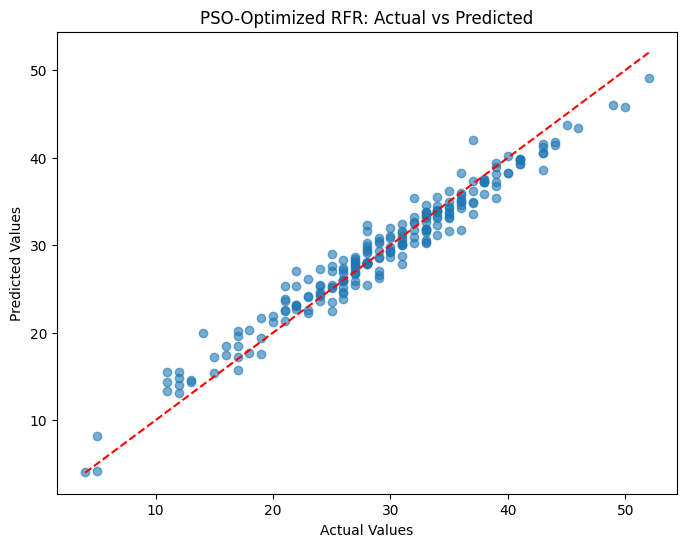

In [8]:
# Random Forest with PSO
best_params_rfr, X_train, X_val, y_train, y_val = pso_rfr(X, y)
final_rfr = RandomForestRegressor(
    n_estimators=best_params_rfr['n_estimators'],
    max_depth=best_params_rfr['max_depth'],
    min_samples_split=best_params_rfr['min_samples_split'],
    min_samples_leaf=best_params_rfr['min_samples_leaf'],
    random_state=42
)
final_rfr.fit(X_train, y_train)
y_pred_rfr = final_rfr.predict(X_val)
evaluate_and_plot('PSO-Optimized RFR', y_val, y_pred_rfr)